# Stream B

In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from PIL import Image
from IPython.display import display

import slicer_wsidicom as S   # slicer_wsidicom.py must be in this folder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
SLIDE = ("/Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0")   # <-- the folder
OUT = "./tiles_out"
os.makedirs(OUT, exist_ok=True)

## Sanity-check one region before tiling

Confirm the pyramid is what the tiler assumes: more than one level, each ~half the
previous (wsidicom is 2x per level). Eyeball one full-res tile and the thumbnail.

level_dimensions: [(57767, 21886), (14441, 5471), (3610, 1367)]
ratios level0/levelN (want ~2, 4, 8 ...): [1.0, 4.0, 16.0]


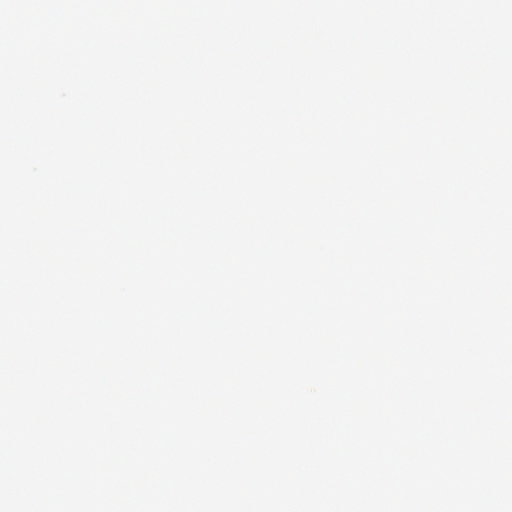

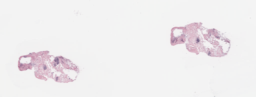

In [11]:
from wsidicom import WsiDicom

with WsiDicom.open(SLIDE) as slide:
    dims = [(l.size.width, l.size.height) for l in slide.levels]
    print("level_dimensions:", dims)
    region = slide.read_region((0, 0), 0, (512, 512)).convert("RGB")
    thumb  = slide.read_thumbnail((256, 256)).convert("RGB")

print("ratios level0/levelN (want ~2, 4, 8 ...):",
      [round(dims[0][0]/w, 2) for (w, h) in dims])
display(region)
display(thumb)

## Validate single-threaded

`parallel=False` runs a plain loop so any error surfaces as a real traceback.
Always do this first on `level=0`.

In [12]:
n_x, n_y, lowres, ct = S.tile(SLIDE, OUT, level=0, parallel=False)
print(f"grid {n_x} x {n_y}, kept {ct} tiles")

slide: /Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0
level_dimensions: [(57767, 21886), (14441, 5471), (3610, 1367)]
using list level 0 -> pyramid index 0, downsample 1x, size 57767x21886
grid: n_x=231, n_y=87, stepsize=250, tile=299


KeyboardInterrupt: 

### B1 - contact-sheet montage

contact sheet: ./tiles_out/contact_sheet.png


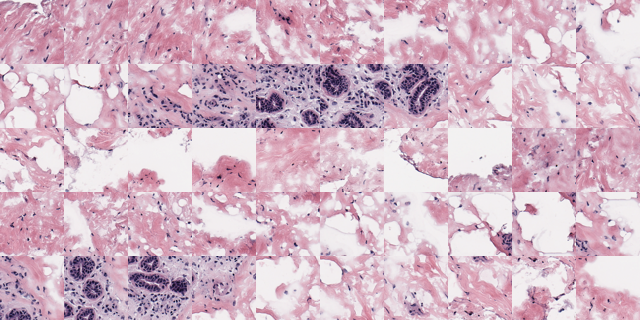

In [13]:
# contact-sheet montage of ~50 tiles
sheet_path = os.path.join(OUT, "contact_sheet.png")
S.contact_sheet(OUT, sheet_path)
display(Image.open(sheet_path))

### B2 - blank-fraction histogram

Scans every candidate tile (no saving) and plots the distribution with the
`blank_max` line. `sample_stride=4` subsamples columns for speed; drop to 1 for the
full picture. This is the figure that feeds threshold tuning in Analysis A4.

In [14]:
def plot_blank_histogram(fractions, out_path, blank_max=0.8, bins=50):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.hist(fractions, bins=bins)
    plt.axvline(blank_max, color="red", linestyle="--",
                label="blank_max = {}".format(blank_max))
    plt.xlabel("blank fraction")
    plt.ylabel("tile count")
    plt.title("Blank-fraction distribution (tiles kept left of the line)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.close()
    print("histogram:", out_path)

histogram: ./tiles_out/blank_hist.png


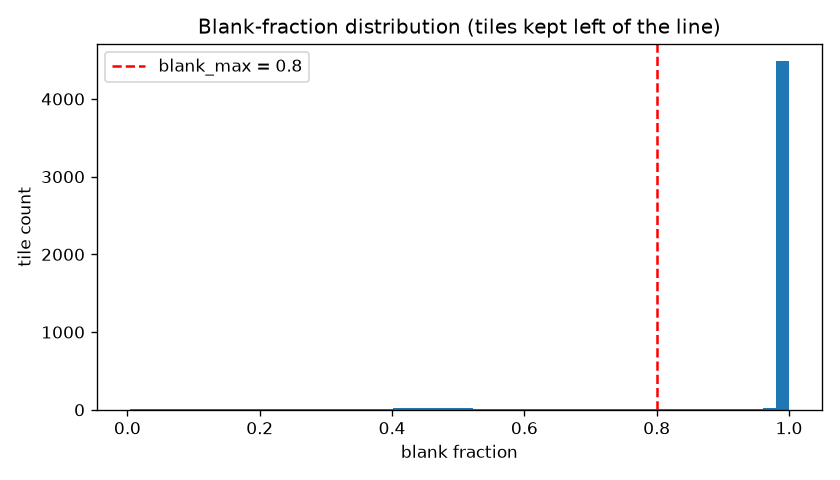

In [15]:
hist_path = os.path.join(OUT, "blank_hist.png")
fractions = S.scan_blank_fractions(SLIDE, level=0, sample_stride=4)
plot_blank_histogram(fractions, hist_path, blank_max=0.8)
display(Image.open(hist_path))

## (Optional) turn on parallelism

Works because `v_slide` is imported from `tiler_wsidicom.py`, so spawned
workers can re-import it. If you instead pasted the functions into a cell, this
will fail - use `parallel=False` above. Also note: a Pool inside a notebook can be
flaky on some macOS setups; if it hangs, restart the kernel and rerun, or just keep
`parallel=False`.

In [ ]:
n_x, n_y, lowres, ct = S.tile(SLIDE, OUT, level=0, parallel=True)
print(f"parallel run kept {ct} tiles")